In [19]:
!pip install git+https://github.com/the-aerospace-corporation/radiomana.git

import os
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import radiomana

folder_path = "/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main"
os.environ["DSET_FIOT_HIGHWAY2"] = folder_path

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/the-aerospace-corporation/radiomana.git to /tmp/pip-req-build-yr0_mv4w
  Running command git clone --filter=blob:none --quiet https://github.com/the-aerospace-corporation/radiomana.git /tmp/pip-req-build-yr0_mv4w
  Resolved https://github.com/the-aerospace-corporation/radiomana.git to commit 73de6b530f392c2fb3d11c3eefbc7a9a4590e803
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [20]:
import radiomana 
from collections import Counter
dataset = radiomana.Highway2Dataset()

CLASS_LABELS = {
    0: "None (Type 1)",
    1: "None (Type 2)",
    2: "None (Type 3)",
    3: "None (Type 4)",
    4: "Chirp, high distance",
    5: "Chirp, medium distance",
    6: "Chirp, small distance",
    7: "Cigarette lighter 1",
    8: "Cigarette lighter 2",
}
EXPECTED_SHAPE = (512, 243)
RNG_SEED = 42
TEST_FRAC = 0.2

def try_get_items(ds):
    """
    Returns (paths, labels) if the dataset exposes lightweight metadata.
    Otherwise returns (None, None).
    """
    if hasattr(ds, "items"):
        try:
            paths = [p for p, y in ds.items]
            labels = [int(y) for p, y in ds.items]
            return paths, labels
        except Exception:
            pass
    # Some versions might use .samples or .index — add probes here if needed
    return None, None

def get_labels_and_optional_paths(ds):
    paths, labels = try_get_items(ds)
    if labels is not None:
        return paths, labels

    # Fallback (slower): index the dataset (could load arrays). We’ll stop if it’s too slow for you.
    print("Falling back to indexing to read labels (may take a while)…")
    labels = []
    maybe_paths = []
    for i in range(len(ds)):
        x, y = ds[i]
        try:
            y_val = int(getattr(y, "item", lambda: y)())
        except Exception:
            y_val = int(y)
        labels.append(y_val)
        # If the item returns a path somewhere (some datasets do), keep it; otherwise None
        maybe_paths.append(None)
    return maybe_paths, labels

paths, labels = get_labels_and_optional_paths(dataset)
num_classes = len(set(labels))
print(f"Found labels for {len(labels)} items across {num_classes} classes.")

counts = Counter(labels)

for cls in sorted(CLASS_LABELS.keys()):
    n = counts.get(cls, 0)
    pct = (n / total * 100) if total else 0.0
    print(f"Class {cls:>1} – {CLASS_LABELS[cls]:<22}: {n:>6}  ({pct:6.2f}%)")

# Also report anything outside your known mapping (just in case)
unknown_classes = sorted(k for k in counts.keys() if k not in CLASS_LABELS)
if unknown_classes:
    print("\n⚠️ Found labels not in CLASS_LABELS:")
    for cls in unknown_classes:
        n = counts[cls]
        pct = (n / total * 100) if total else 0.0
        print(f"Class {cls}: {n} ({pct:.2f}%)")

Found labels for 12915 items across 9 classes.
Class 0 – None (Type 1)         :   4102  (  0.00%)
Class 1 – None (Type 2)         :   2247  (  0.00%)
Class 2 – None (Type 3)         :   5451  (  0.00%)
Class 3 – None (Type 4)         :     46  (  0.00%)
Class 4 – Chirp, high distance  :    172  (  0.00%)
Class 5 – Chirp, medium distance:    284  (  0.00%)
Class 6 – Chirp, small distance :    332  (  0.00%)
Class 7 – Cigarette lighter 1   :    155  (  0.00%)
Class 8 – Cigarette lighter 2   :    126  (  0.00%)


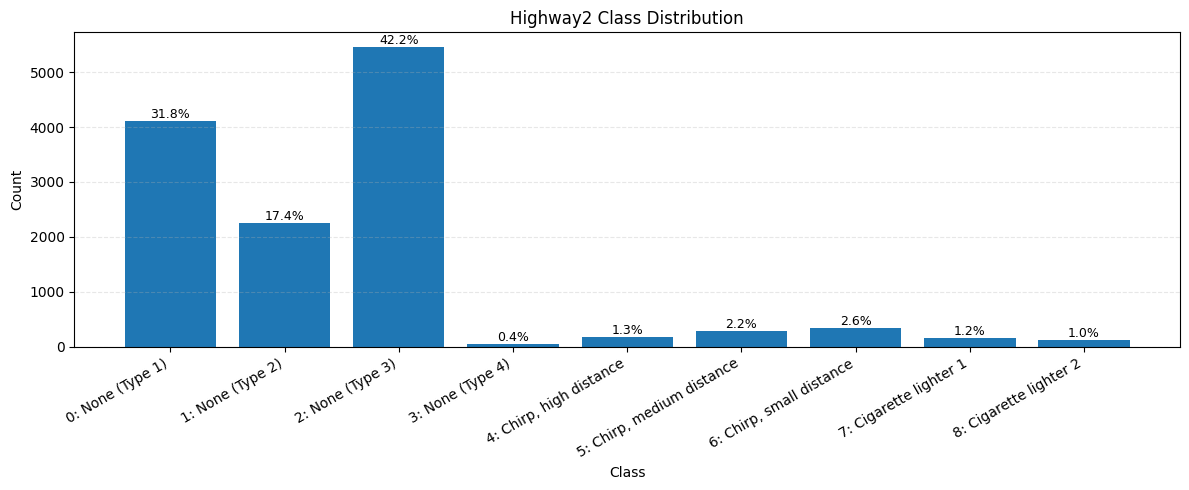

In [15]:
import matplotlib.pyplot as plt
import numpy as np

total = sum(counts.values())

classes = sorted(CLASS_LABELS.keys())
values  = [counts.get(c, 0) for c in classes]
names   = [f"{c}: {CLASS_LABELS[c]}" for c in classes]
pct     = [(v / total * 100.0) if total else 0.0 for v in values]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(classes))

bars = ax.bar(x, values) 
ax.set_title("Highway2 Class Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("Class")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")

# Add percentage labels above bars
for rect, p in zip(bars, pct):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2.0, height,
            f"{p:,.1f}%", ha="center", va="bottom", fontsize=9)

ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# --- Dataset class ---
class SpectrogramDataset(Dataset):
    def __init__(self, folder_path, txt_file):
        self.folder_path = folder_path
        self.samples = []
        with open(txt_file, "r") as f:
            for line in f:
                file_path, label = line.strip().split()
                full_path = os.path.join(folder_path, file_path)
                label = int(label)
                self.samples.append((full_path, label))
                
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        data = np.load(file_path)
        
        # Normalize each sample (min-max)
        data = (data - data.min()) / (data.max() - data.min() + 1e-6)
        
        data_tensor = torch.tensor(data, dtype=torch.float32).unsqueeze(0)  # add channel dim
        return data_tensor, label

# --- CNN model with dynamic flatten size ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=9, input_shape=(1, 64, 64)):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        with torch.no_grad():
            x = torch.zeros(1, *input_shape)
            x = self.pool(torch.relu(self.bn1(self.conv1(x))))
            x = self.pool(torch.relu(self.bn2(self.conv2(x))))
            x = self.pool(torch.relu(self.bn3(self.conv3(x))))
            flatten_size = x.numel()
        
        self.fc1 = nn.Linear(flatten_size, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# --- Training function ---
def train_model():
    folder_path = "/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main"
    train_txt = os.path.join(folder_path, "train.txt")
    batch_size = 32
    epochs = 10
    learning_rate = 0.001
    num_classes = 9
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    dataset = SpectrogramDataset(folder_path, train_txt)
    dataset_size = len(dataset)
    
    if dataset_size == 0:
        print("Dataset is empty! Check file paths.")
        return
    
    # Get input shape from first sample
    sample_data, _ = dataset[0]
    input_shape = sample_data.shape  # e.g. (1, 64, 64)
    print(f"Input data shape: {input_shape}")
    
    train_size = int(0.8 * dataset_size)
    val_size = dataset_size - train_size
    
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    
    model = SimpleCNN(num_classes=num_classes, input_shape=input_shape).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_loss = running_loss / train_size
        train_acc = correct / total
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_loss /= val_size
        val_acc = val_correct / val_total
        
        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    print("Training complete.")

if __name__ == "__main__":
    train_model()
